<a id="mixed-data"></a>
# Mixed Discrete-Continuous Data

Real-world time series often contain both continuous measurements and discrete variables (binary regime indicators, categorical states, count data). Standard CI tests (ParCorr, KCI, DFCIT, etc.) assume continuous inputs — applying them directly to discrete columns can give incorrect results because the rank transform or kernel bandwidth breaks down on discrete values.

`causal-ts` handles this automatically: `run_cdnots` detects discrete columns in your DataFrame and wraps the CI test in a `StratifiedCIT` — which partitions the sample by discrete conditioning values and runs the inner test within each stratum. No code changes needed from the user.

**What goes wrong without discrete handling?**
When binary regime variables (B1, B2) appear in the conditioning set during CI testing, treating them as continuous gives incorrect partial correlations. This causes spurious lagged edges *between* the binary variables themselves — edges that would be correctly rejected if the test operated within each discrete stratum.

In [ ]:
from causalts.cdnots.phase3_utils import run_cdnots
from causalts.synthetic_data.mixed_datasets import mixed_c
from causalts.ci_tests import ParCorrGPU
from causalts.utils import evaluate_graph as _eval
import numpy as np, warnings

# mixed_c: 2 binary regime variables B1, B2 + 4 continuous variables X0-X3.
# B1 and B2 drive the continuous variables. When B1/B2 enter the conditioning
# set during CI testing, treating them as continuous produces incorrect p-values
result_mixed = mixed_c(seed=35, T=500)
df_mixed = result_mixed['df']
gt_mixed = result_mixed['ground_truth']
d_mixed  = df_mixed.shape[1]
cols     = list(df_mixed.columns)
print(f"Dataset: {d_mixed} variables, discrete={result_mixed['discrete_cols']}, "
      f"{int(gt_mixed.sum())} true edges, max_lag={result_mixed['max_lag']}")

# --- With discrete handling (auto-detected, StratifiedCIT) ---
ci_disc = ParCorrGPU(np.zeros((2, 2)), device='cpu')
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    res_disc = run_cdnots(
        df=df_mixed, indep_test=ci_disc, num_lags=result_mixed['max_lag'],
        include_C=False, alpha=0.05,
    )
if w:
    print(f'\n⚠️  {w[0].message}')

# --- Without discrete handling (treat everything as continuous) ---
ci_cont = ParCorrGPU(np.zeros((2, 2)), device='cpu')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    res_cont = run_cdnots(
        df=df_mixed, indep_test=ci_cont, num_lags=result_mixed['max_lag'],
        include_C=False, alpha=0.05, discrete_cols=[],
    )

est_disc = res_disc.cg_tig[:d_mixed, :d_mixed, :]
est_cont = res_cont.cg_tig[:d_mixed, :d_mixed, :]
m_disc = _eval(est_disc, gt_mixed)
m_cont = _eval(est_cont, gt_mixed)

print(f'\n{"Method":<25} {"F1":>6} {"Prec":>6} {"Rec":>6} {"SHD":>5}')
print('-' * 48)
print(f'{"With discrete handling":<25} {m_disc["F1"]:>6.3f} {m_disc["Precision"]:>6.3f} '
      f'{m_disc["TPR"]:>6.3f} {m_disc["SHD"]:>5}')
print(f'{"Without discrete handling":<25} {m_cont["F1"]:>6.3f} {m_cont["Precision"]:>6.3f} '
      f'{m_cont["TPR"]:>6.3f} {m_cont["SHD"]:>5}')
print()
print('Spurious edges introduced WITHOUT discrete handling:')
for c in range(d_mixed):
    for e in range(d_mixed):
        for lag in range(gt_mixed.shape[2]):
            if est_cont[c,e,lag] and not gt_mixed[c,e,lag]:
                print(f'  FP: {cols[c]}(t-{lag}) -> {cols[e]}')


Dataset: 6 variables, discrete=['B1', 'B2'], 11 true edges, max_lag=2

⚠️  Detected discrete columns: ['B1', 'B2']. Your CI test (ParCorrGPU) does not natively handle discrete data — wrapping it in StratifiedCIT for correct conditioning. Pass discrete_cols=[] to disable auto-wrapping.

Method                        F1   Prec    Rec   SHD
------------------------------------------------
With discrete handling     0.909  0.909  0.909     2
Without discrete handling  0.880  0.786  1.000     3

Spurious edges introduced WITHOUT discrete handling:
  FP: B2(t-2) -> B1
  FP: B2(t-2) -> B2
  FP: X1(t-2) -> X3


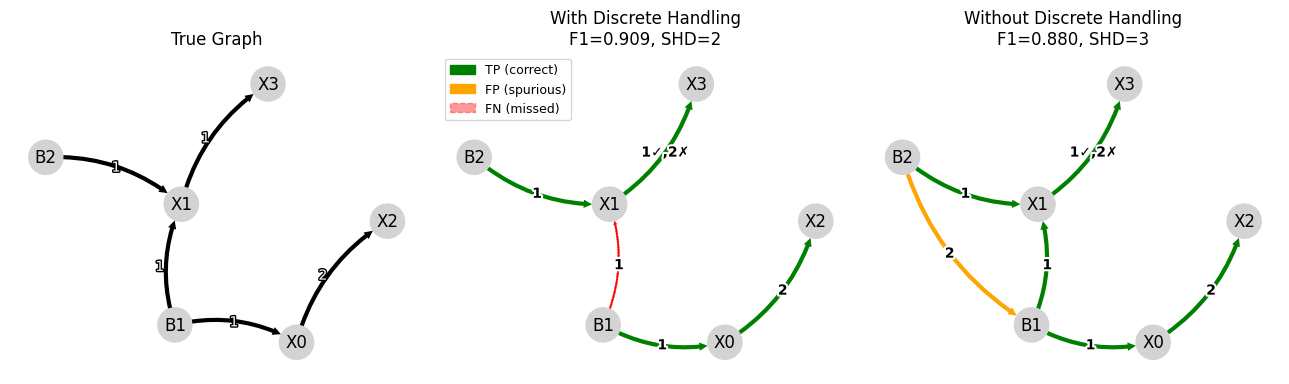

In [3]:
import matplotlib.pyplot as plt
import causalts.plotting as tp

var_names = df_mixed.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

_, _, pos = tp.plot_graph(
    graph=gt_mixed, var_names=var_names,
    arrow_linewidth=3, show_colorbar=False,
    fig_ax=(fig, axes[0]), return_pos=True, node_layout='fdp'
)
axes[0].set_title('True Graph', fontsize=12)

tp.compare_graphs(
    graph_true=gt_mixed, graph_discovered=est_disc,
    var_names=var_names, node_pos=pos,
    arrow_linewidth=3, show_legend=True,
    fig_ax=(fig, axes[1]), legend_loc='upper left',
)
axes[1].set_title(f'With Discrete Handling\nF1={m_disc["F1"]:.3f}, SHD={m_disc["SHD"]}', fontsize=12)

tp.compare_graphs(
    graph_true=gt_mixed, graph_discovered=est_cont,
    var_names=var_names, node_pos=pos,
    arrow_linewidth=3, show_legend=False,
    fig_ax=(fig, axes[2]),
)
axes[2].set_title(f'Without Discrete Handling\nF1={m_cont["F1"]:.3f}, SHD={m_cont["SHD"]}', fontsize=12)

plt.tight_layout()
plt.show()


## Limitations of StratifiedCIT

| Limitation | Details |
|------------|---------|
| **Contemporaneous edges from discrete variables are undetectable** | Within each stratum the discrete variable is constant (zero variance), so `B(t)→X(t)` at lag-0 can never pass a CI test. Only lagged edges `B(t-k)→X(t)` with k≥1 are detectable. |
| **Sample size cost** | The sample is split by discrete values. With k binary variables, each stratum has ~T/2^k observations. Power drops quickly: 2 binary variables at T=500 gives ~125 samples per stratum. |
| **Only beneficial when discrete variables enter the conditioning set** | If a discrete variable has no outgoing edges (pure leaf), it never appears in a conditioning set and StratifiedCIT adds computation with no accuracy benefit. |
| **Ordering matters for multi-way discrete** | For discrete variables with many levels, some strata may be too small for a valid CI test and are skipped. |

**When to use `discrete_cols=[]` (opt-out):**
- You know the discrete variable has no outgoing edges
- T is small and sample splitting would hurt power more than incorrect conditioning

**Alternatives:** `CMIknnMixedGPU` handles mixed data natively without splitting — it uses a mixed-variable k-NN estimator that treats discrete and continuous variables jointly.
